In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# Import the parser you built (assuming it's in src/parser.py)
from parser import BDDParser, FrameRecord

# Define paths (Adjust to your local structure)
TRAIN_JSON = "E:\\interview\\BoschProject\\data\\bdd100k_labels_release\\bdd100k\\labels\\bdd100k_labels_images_train.json"
VAL_JSON = "E:\\interview\\BoschProject\\data\\bdd100k_labels_release\\bdd100k\\labels\\bdd100k_labels_images_val.json"
CONFIG_PATH = "E:\\interview\\BoschProject\\data\\bdd100k_labels_release\\bdd100k\\configs\\bdd100k_2D_labels_config.json"
IMAGE_WIDTH = 1280
IMAGE_HEIGHT = 720
IMAGE_AREA = IMAGE_WIDTH * IMAGE_HEIGHT

### Step 1: Data Extraction
Instead of writing raw JSON processing logic here, we instantiate our `BDDParser`. We will iterate through the parsed `FrameRecord` objects and flatten them into two Pandas DataFrames:
1. **`df_frames`**: Contains image-level metadata (weather, scene, timeofday).
2. **`df_objects`**: Contains bounding-box level data (category, area, aspect ratio, occlusion).

In [8]:
def extract_to_dataframes(json_path: str, config_path: str, split_name: str):
    """Parses the JSON and extracts data into structured DataFrames."""
    parser = BDDParser(json_path=json_path, config_path=config_path)
    
    frames_data = []
    objects_data = []
    
    for frame in parser.load_and_filter_stream():
        # 1. Frame-level data
        attrs = frame.attributes
        frames_data.append({
            "name": frame.name,
            "split": split_name,
            "weather": attrs.weather,
            "scene": attrs.scene,
            "timeofday": attrs.timeofday,
            "timestamp": frame.timestamp,
            "object_count": len(frame.labels) if frame.labels else 0
        })
        
        # 2. Object-level data
        if frame.labels:
            for lbl in frame.labels:
                box = lbl.box2d
                width = max(box.x2 - box.x1, 1.0)
                height = max(box.y2 - box.y1, 1.0)
                area = width * height
                
                objects_data.append({
                    "frame_name": frame.name,
                    "split": split_name,
                    "category": lbl.category,
                    "occluded": lbl.attributes.occluded,
                    "truncated": lbl.attributes.truncated,
                    "area_ratio": area / IMAGE_AREA,
                    "aspect_ratio": width / height
                })
                
    return pd.DataFrame(frames_data), pd.DataFrame(objects_data)

print("Parsing Train Split...")
df_frames_train, df_objects_train = extract_to_dataframes(TRAIN_JSON, CONFIG_PATH, "train")

print("Parsing Val Split...")
df_frames_val, df_objects_val = extract_to_dataframes(VAL_JSON, CONFIG_PATH, "val")

# Combine for holistic analysis
df_frames = pd.concat([df_frames_train, df_frames_val], ignore_index=True)
df_objects = pd.concat([df_objects_train, df_objects_val], ignore_index=True)

print(f"Total Frames Extracted: {len(df_frames):,}")
print(f"Total Objects Extracted: {len(df_objects):,}")

2026-06-02 16:23:44,538 [INFO] Starting parsing stream for bdd100k_labels_images_train.json...


Parsing Train Split...


2026-06-02 16:24:10,864 [INFO] Stream complete. Valid frames: 69863 | Dropped: 0
2026-06-02 16:24:13,382 [INFO] Starting parsing stream for bdd100k_labels_images_val.json...


Parsing Val Split...


2026-06-02 16:24:15,240 [INFO] Stream complete. Valid frames: 10000 | Dropped: 0


Total Frames Extracted: 79,863
Total Objects Extracted: 1,472,397


### Step 2: Class Imbalance & Split Verification
We must prove that the validation set is a representative slice of the training set. We will calculate the distribution of object classes and highlight the severe imbalance (e.g., Cars vs. Trains).

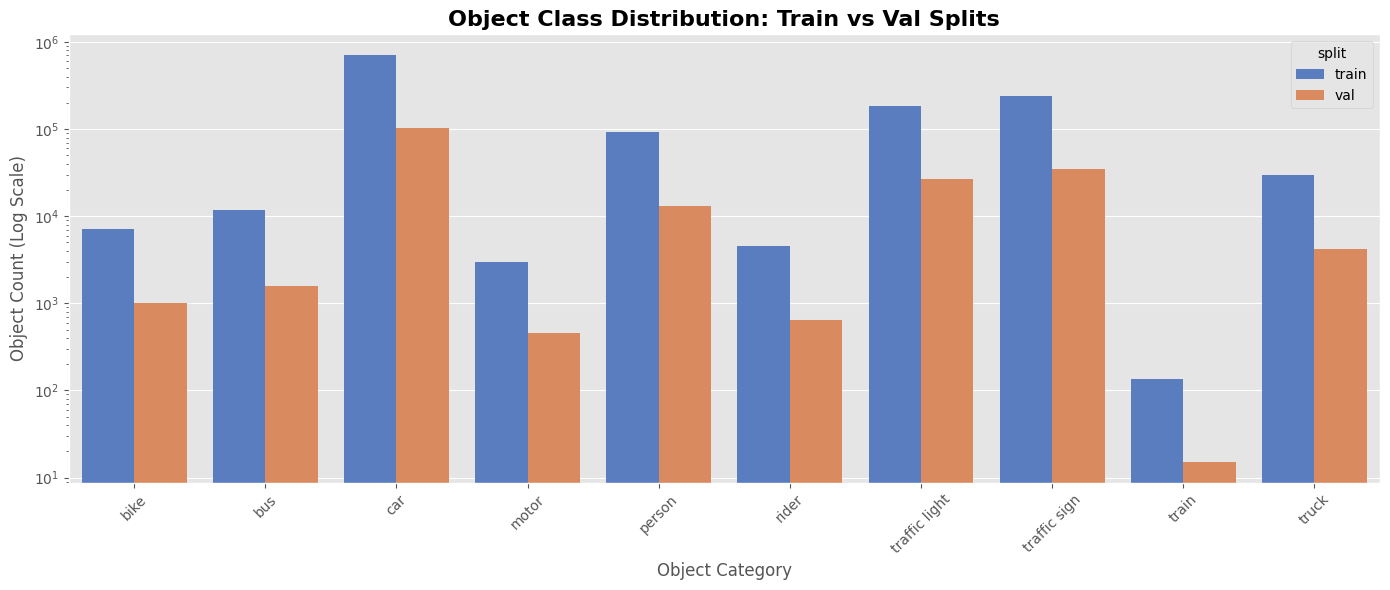

SEVERE IMBALANCE METRIC:
Ratio of Cars to Riders: 157.9 : 1
Ratio of Cars to Trains: 5244.2 : 1


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Count objects by category and split
class_counts = df_objects.groupby(['category', 'split']).size().reset_index(name='count')

# Plotting
sns.barplot(data=class_counts, x='category', y='count', hue='split', ax=ax)
ax.set_title('Object Class Distribution: Train vs Val Splits', fontsize=16, fontweight='bold')
ax.set_yscale('log') # Log scale is crucial due to extreme imbalance
ax.set_ylabel('Object Count (Log Scale)')
ax.set_xlabel('Object Category')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print exact imbalance ratios for the train set
train_objs = df_objects[df_objects['split'] == 'train']
counts = train_objs['category'].value_counts()
print(f"SEVERE IMBALANCE METRIC:")
print(f"Ratio of Cars to Riders: {counts.get('car', 0) / counts.get('rider', 1):.1f} : 1")
print(f"Ratio of Cars to Trains: {counts.get('car', 0) / counts.get('train', 1):.1f} : 1")

### Step 3: Weather, Time of Day, and Scene
Autonomous vehicles fail when environmental conditions change. Here, we analyze the metadata distribution to see how much of our dataset represents "perfect driving conditions" versus edge cases.

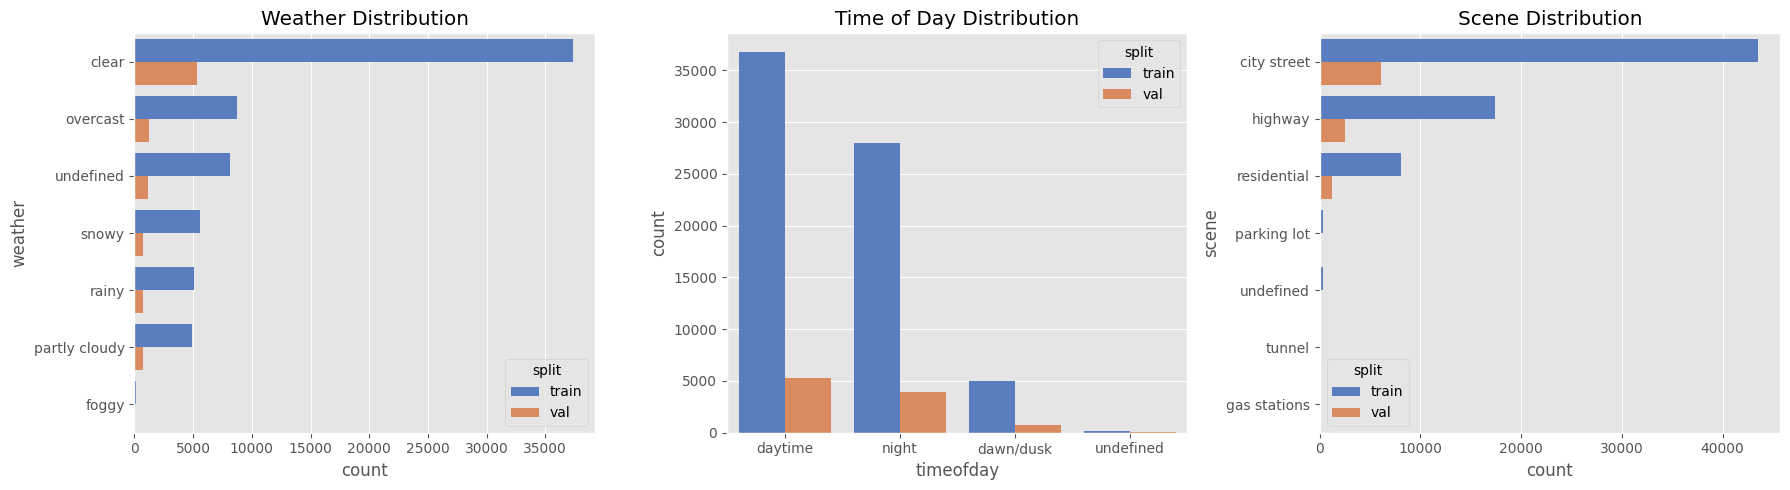

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Weather Distribution
sns.countplot(data=df_frames, y='weather', hue='split', ax=axes[0], order=df_frames['weather'].value_counts().index)
axes[0].set_title('Weather Distribution')

# Time of Day Distribution
sns.countplot(data=df_frames, x='timeofday', hue='split', ax=axes[1], order=df_frames['timeofday'].value_counts().index)
axes[1].set_title('Time of Day Distribution')

# Scene Distribution
sns.countplot(data=df_frames, y='scene', hue='split', ax=axes[2], order=df_frames['scene'].value_counts().index)
axes[2].set_title('Scene Distribution')

plt.tight_layout()
plt.show()

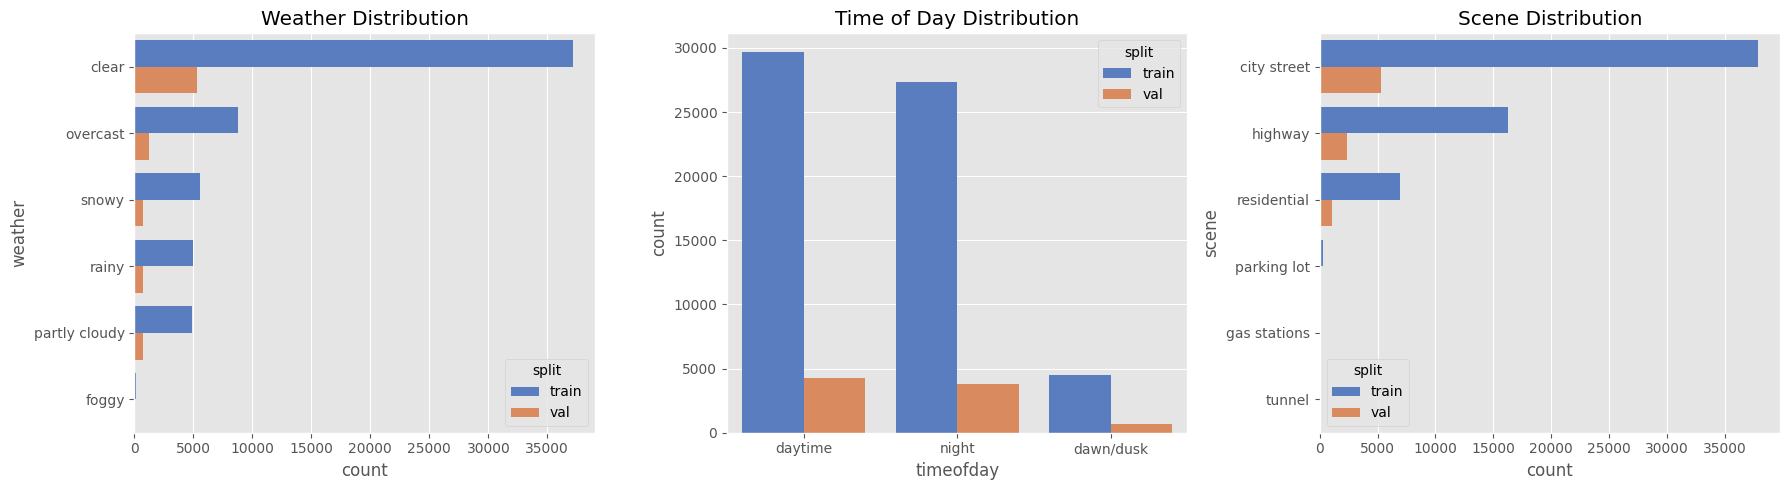

In [13]:
# Create a clean DataFrame that drops 'undefined' conditions
df_clean_frames = df_frames[
    (df_frames['weather'] != 'undefined') & 
    (df_frames['timeofday'] != 'undefined') & 
    (df_frames['scene'] != 'undefined')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use the clean DataFrame (df_clean_frames) for plotting
sns.countplot(data=df_clean_frames, y='weather', hue='split', ax=axes[0], order=df_clean_frames['weather'].value_counts().index)
axes[0].set_title('Weather Distribution')

sns.countplot(data=df_clean_frames, x='timeofday', hue='split', ax=axes[1], order=df_clean_frames['timeofday'].value_counts().index)
axes[1].set_title('Time of Day Distribution')

sns.countplot(data=df_clean_frames, y='scene', hue='split', ax=axes[2], order=df_clean_frames['scene'].value_counts().index)
axes[2].set_title('Scene Distribution')

plt.tight_layout()
plt.show()

### Step 4: Geometry Anomalies
Models struggle with objects that are either too small to resolve (micro-boxes) or heavily distorted (extreme aspect ratios). 
* **Micro-boxes:** Objects occupying less than 0.1% of the image.
* **Extreme Aspect Ratios:** Ratios > 5.0 (extremely wide) or < 0.2 (extremely tall).

Anomaly Report:
 - Micro-boxes detected: 777,859 (52.83% of all objects)
 - Extreme aspect ratios detected: 7,131 (0.48% of all objects)


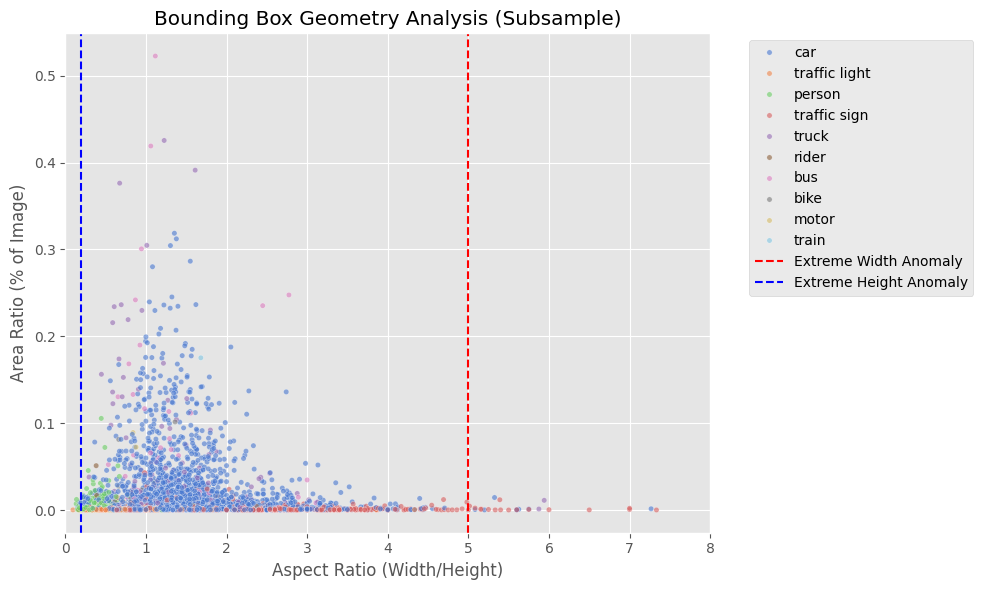

In [11]:
# Identify Anomalies
micro_boxes = df_objects[df_objects['area_ratio'] < 0.001]
extreme_aspects = df_objects[(df_objects['aspect_ratio'] > 5.0) | (df_objects['aspect_ratio'] < 0.2)]

print(f"Anomaly Report:")
print(f" - Micro-boxes detected: {len(micro_boxes):,} ({(len(micro_boxes)/len(df_objects))*100:.2f}% of all objects)")
print(f" - Extreme aspect ratios detected: {len(extreme_aspects):,} ({(len(extreme_aspects)/len(df_objects))*100:.2f}% of all objects)")

# Plot Aspect Ratio vs Area Ratio
plt.figure(figsize=(10, 6))
# Sample 10,000 points to avoid memory lag in notebook plotting
sample_objs = df_objects.sample(min(10000, len(df_objects)), random_state=42)

sns.scatterplot(data=sample_objs, x='aspect_ratio', y='area_ratio', hue='category', alpha=0.6, s=15)
plt.axvline(x=5.0, color='red', linestyle='--', label='Extreme Width Anomaly')
plt.axvline(x=0.2, color='blue', linestyle='--', label='Extreme Height Anomaly')
plt.title('Bounding Box Geometry Analysis (Subsample)')
plt.xlabel('Aspect Ratio (Width/Height)')
plt.ylabel('Area Ratio (% of Image)')
plt.xlim(0, 8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 5: Hard Sample Mining
We will assign a "Hard Sample Score" to every frame. A frame gets points if it happens at night, in bad weather, or contains highly occluded target objects (like pedestrians). Finding these frames proves our pipeline can automatically surface the data that crashes real ADAS systems.

In [12]:
def calculate_hard_score(row):
    score = 0
    if row['weather'] in ['snowy', 'foggy', 'rainy']:
        score += 3
    if row['timeofday'] == 'night':
        score += 2
    return score

# Calculate environmental base score
df_frames['hard_score'] = df_frames.apply(calculate_hard_score, axis=1)

# Calculate occlusion penalty
# Group by frame and count occluded objects
occlusion_counts = df_objects[df_objects['occluded'] == True].groupby('frame_name').size()
occlusion_df = occlusion_counts.reset_index(name='occluded_count')

# Merge and add occlusion penalty (0.5 points per occluded object)
df_hard = pd.merge(df_frames, occlusion_df, left_on='name', right_on='frame_name', how='left')
df_hard['occluded_count'] = df_hard['occluded_count'].fillna(0)
df_hard['total_hard_score'] = df_hard['hard_score'] + (df_hard['occluded_count'] * 0.5)

# Extract the Top 10 Absolute Hardest Scenarios
top_hard_samples = df_hard.sort_values(by='total_hard_score', ascending=False).head(10)

print("🚨 TOP 10 HARDEST DRIVING SCENARIOS IDENTIFIED 🚨")
display_cols = ['name', 'split', 'weather', 'timeofday', 'scene', 'object_count', 'occluded_count', 'total_hard_score']
display(top_hard_samples[display_cols].reset_index(drop=True))

🚨 TOP 10 HARDEST DRIVING SCENARIOS IDENTIFIED 🚨


,name,split,weather,timeofday,scene,object_count,occluded_count,total_hard_score
0,1cd6b4e9-15d5d536.jpg,train,clear,daytime,highway,78,64.0,32.0
1,8d091799-5c28a01c.jpg,train,clear,night,city street,63,58.0,31.0
2,a3d81283-5b9afb34.jpg,train,overcast,daytime,highway,84,62.0,31.0
3,7a9d6ddb-f6db12be.jpg,train,clear,night,city street,91,52.0,28.0
4,9f813b6a-18e666e2.jpg,train,clear,daytime,city street,85,55.0,27.5
5,17d2c5d1-2e9125f2.jpg,train,clear,night,city street,59,48.0,26.0
6,7daef12e-031f1b87.jpg,train,undefined,daytime,highway,63,51.0,25.5
7,5a70bb60-021b9683.jpg,train,overcast,dawn/dusk,highway,52,50.0,25.0
8,23c3afd8-f925d1a6.jpg,train,clear,night,city street,53,46.0,25.0
9,4419d300-4a38ca31.jpg,train,overcast,dawn/dusk,highway,57,50.0,25.0


### Conclusion
By executing this notebook, we have mathematically validated our assumptions:
1. The Train and Val splits share nearly identical distributions.
2. The dataset has a severe class imbalance that we must account for during model training (e.g., Focal Loss).
3. We successfully isolated severe anomalies and edge-case hard samples using our taxonomy metadata.

**Next Step for Deployment:** We will now port the core statistical logic of this notebook into `src/eda_analyzer.py`. That script will generate a lightweight `eda_report.json` which our interactive `Streamlit` dashboard will consume, completely decoupling our heavy Pandas processing from our UI.

In [15]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.9 MB 5.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 5.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 3.3 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 3.3 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 3.3 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 3.0 MB/s eta 0:00:02
   ------------------------------- -------- 7.9/9.9 MB 3.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
